In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [2]:

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1650


In [3]:
def downscale_x4(img):

    h, w = img.shape[:2]

    small = cv2.resize(img, (w//4, h//4),
                       interpolation=cv2.INTER_AREA)

    return cv2.resize(small, (w, h),
                      interpolation=cv2.INTER_CUBIC)

In [4]:
class SRDataset(Dataset):

    def __init__(self, root_dir, img_size=224):

        self.paths = [os.path.join(root_dir,f)
                      for f in os.listdir(root_dir)]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        lr = downscale_x4(img)

        clean = self.transform(img)
        lr = self.transform(lr)

        return lr, clean

In [5]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = SRDataset(DATA_PATH)
loader = DataLoader(dataset,
                    batch_size=8,
                    shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 3000


In [6]:
class Block(nn.Module):

    def __init__(self, a, b):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)


class SRNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            Block(3,64),
            Block(64,64),

            Block(64,128),
            Block(128,128),

            Block(128,64),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [7]:
model = SRNet().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(),
                       lr=1e-3)

In [8]:
EPOCHS = 10
for epoch in range(EPOCHS):

    epoch_loss = 0
    pbar = tqdm(loader)

    for lr, hr in pbar:

        lr = lr.to(device)
        hr = hr.to(device)

        sr = model(lr)

        loss = criterion(sr, hr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pbar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss:",
          epoch_loss/len(loader))

100%|██████████| 375/375 [03:05<00:00,  2.03it/s, loss=0.00417]


Epoch 1 Loss: 0.007134594424938162


100%|██████████| 375/375 [02:54<00:00,  2.15it/s, loss=0.00296]


Epoch 2 Loss: 0.0050821293964982035


100%|██████████| 375/375 [02:40<00:00,  2.34it/s, loss=0.00598]


...

Epoch 8 Loss: 0.0027916329093277455


100%|██████████| 375/375 [02:35<00:00,  2.41it/s, loss=0.0036] 


Epoch 9 Loss: 0.002552618938498199


100%|██████████| 375/375 [02:35<00:00,  2.41it/s, loss=0.00267] 

Epoch 10 Loss: 0.002597802081455787


In [9]:
torch.save(model.state_dict(),
           "SR_x4_model.pth")

print("Super-Resolution model saved")

Super-Resolution model saved


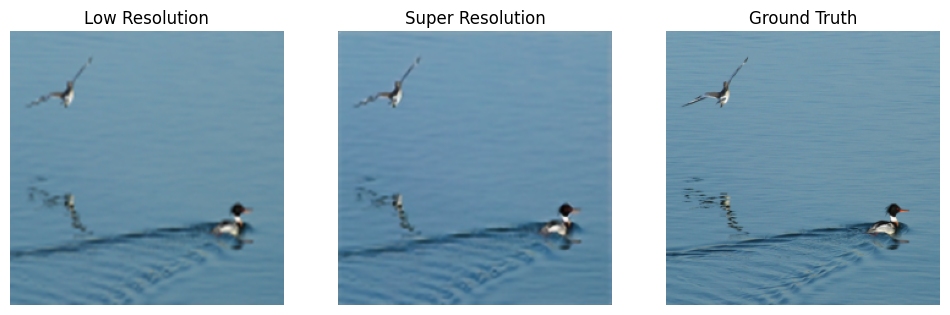

In [10]:
lr, hr = next(iter(loader))

lr = lr.to(device)

with torch.no_grad():
    sr = model(lr).cpu()

def show(img):

    img = img.permute(1,2,0).numpy()
    img = np.clip(img,0,1)

    plt.imshow(img)
    plt.axis("off")

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
show(lr[0].cpu())
plt.title("Low Resolution")

plt.subplot(1,3,2)
show(sr[0])
plt.title("Super Resolution")

plt.subplot(1,3,3)
show(hr[0])
plt.title("Ground Truth")

plt.show()

In [11]:
import math

def compute_psnr(model):

    mse_total = 0

    with torch.no_grad():

        for lr, hr in loader:

            lr = lr.to(device)
            hr = hr.to(device)

            sr = model(lr)

            mse = ((sr-hr)**2).mean().item()
            mse_total += mse

    mse_avg = mse_total / len(loader)

    psnr = 10 * math.log10(1 / mse_avg)

    print("Average MSE:", mse_avg)
    print("PSNR:", psnr, "dB")

compute_psnr(model)

Average MSE: 0.0026127719602858025
PSNR: 25.828984933386124 dB
